# Gradient Descent and the Rosenbrock Function

**Gradient descent** is the simplest first-order optimization method. Starting from $x^0$, it iterates:
$$
x^{k+1} = x^k - \tau \nabla f(x^k),
$$
where $\tau > 0$ is the **step size** (learning rate). For $L$-smooth convex $f$ with step size $\tau \leq 1/L$, the method converges at rate $O(1/k)$ in function values. For $\mu$-strongly convex $f$, the rate improves to linear: $O((1-\mu/L)^k)$.

## The Rosenbrock function

The **Rosenbrock function** (also called the "banana function") is the classic optimization benchmark:
$$
f(x, y) = (1-x)^2 + 100(y - x^2)^2.
$$
It has a unique minimum at $(1, 1)$ where $f = 0$, enclosed in a long, narrow curved valley. The gradient is:
$$
\nabla f = \begin{pmatrix} -2(1-x) - 400x(y-x^2) \\ 200(y-x^2) \end{pmatrix}.
$$
The function is notoriously difficult for gradient descent because:
- The condition number $\kappa = L/\mu \approx 10^4$–$10^6$ forces very small step sizes.
- The gradient nearly vanishes along the valley floor, causing slow progress.

## Convergence and step size selection

For a quadratic $f(x) = \frac{1}{2}x^\top A x - b^\top x$ with eigenvalues $\lambda_{\min} \leq \cdots \leq \lambda_{\max}$:
- The **optimal fixed step** is $\tau^* = 2/(\lambda_{\min}+\lambda_{\max})$.
- Each step reduces the error by factor $(\kappa-1)/(\kappa+1)$ where $\kappa = \lambda_{\max}/\lambda_{\min}$.
- The **exact line search** $\tau^k = \argmin_\tau f(x^k - \tau \nabla f^k)$ is optimal for quadratics but expensive in general.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatLogSlider, IntSlider

plt.rcParams['figure.dpi'] = 120

## Rosenbrock function and its gradient

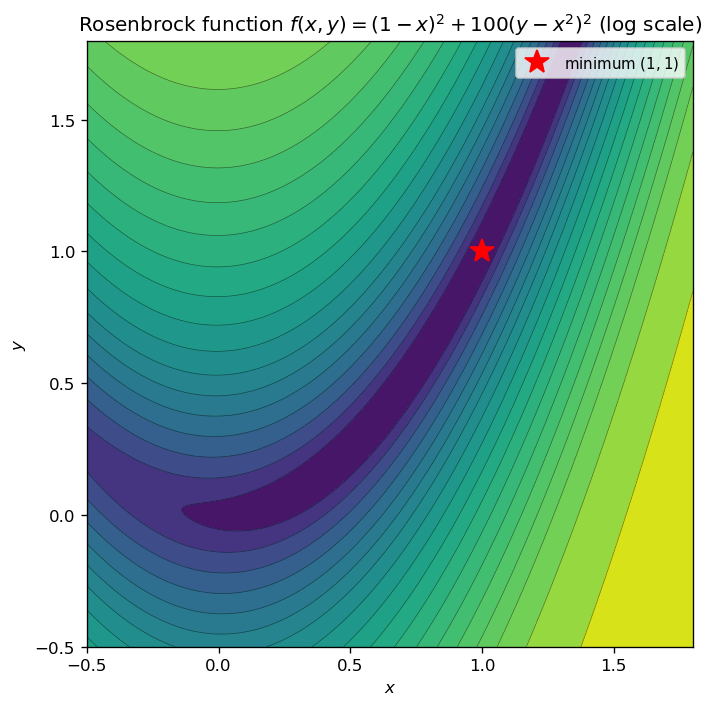

In [2]:
def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(x, y):
    gx = -2*(1-x) - 400*x*(y - x**2)
    gy = 200*(y - x**2)
    return gx, gy

# Display landscape
n = 300
xt = np.linspace(-0.5, 1.8, n)
yt = np.linspace(-0.5, 1.8, n)
Y, X = np.meshgrid(yt, xt)
F = rosenbrock(X, Y)
F_log = np.log1p(F)

fig, ax = plt.subplots(figsize=(6, 6))
v = np.percentile(F_log, np.linspace(0, 100, 20))
ax.contourf(xt, yt, F_log.T, levels=v, cmap='parula' if False else 'viridis')
ax.contour(xt, yt, F_log.T, levels=v, colors='k', linewidths=0.4, alpha=0.5)
ax.plot(1, 1, 'r*', ms=15, label='minimum $(1,1)$')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('Rosenbrock function $f(x,y) = (1-x)^2 + 100(y-x^2)^2$ (log scale)')
ax.legend(fontsize=9); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## Gradient descent trajectories

We run gradient descent from several initial points and compare trajectories for different step sizes. The narrow valley causes oscillations when the step size is too large.

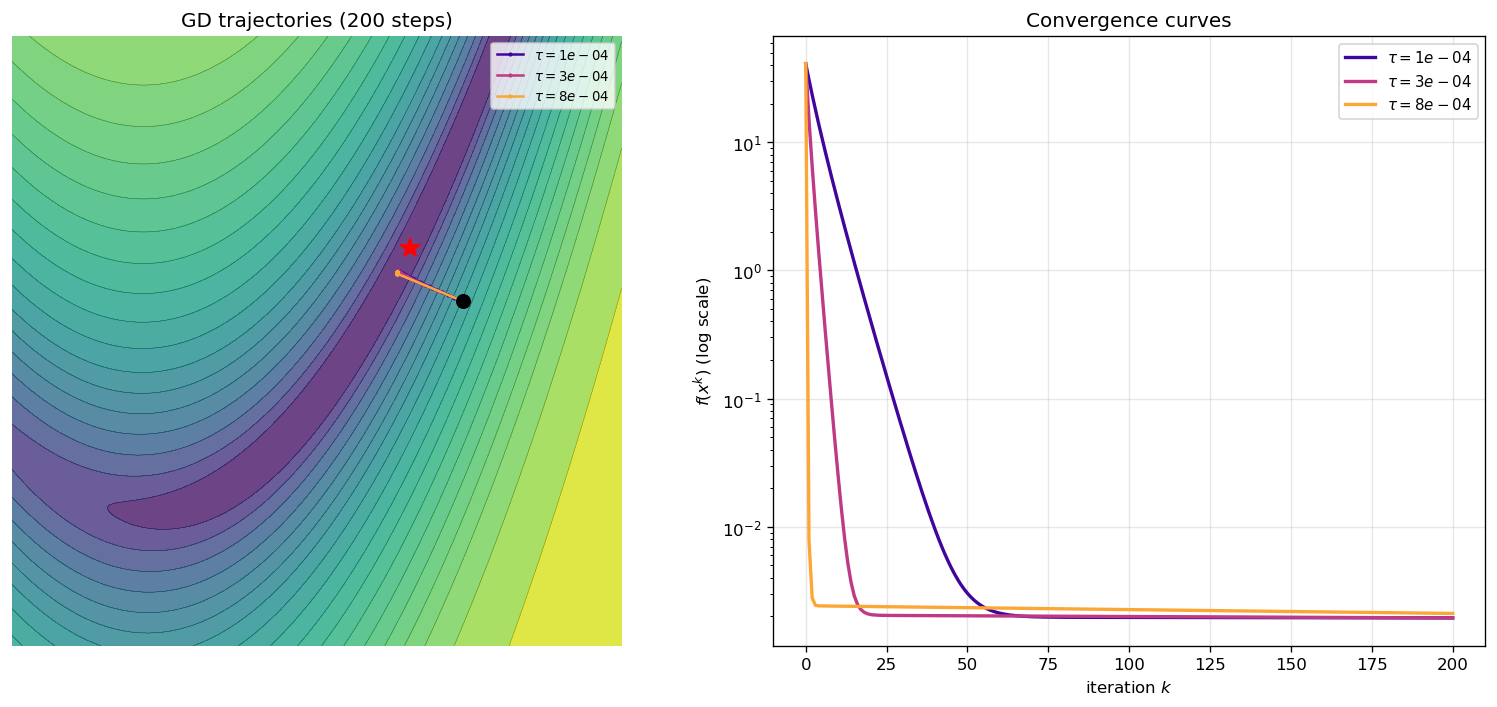

In [3]:
def gradient_descent(x0, y0, tau, n_iter):
    x, y = x0, y0
    traj = [(x, y)]
    fvals = [rosenbrock(x, y)]
    for _ in range(n_iter):
        gx, gy = rosenbrock_grad(x, y)
        x -= tau * gx
        y -= tau * gy
        traj.append((x, y))
        fvals.append(rosenbrock(x, y))
    return np.array(traj), np.array(fvals)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
tau_values = [1e-4, 3e-4, 8e-4]
cols = plt.cm.plasma(np.linspace(0.1, 0.8, len(tau_values)))
x0, y0 = 1.2, 0.8

axes[0].contourf(xt, yt, F_log.T, levels=v, cmap='viridis', alpha=0.8)
axes[0].contour(xt, yt, F_log.T, levels=v, colors='k', linewidths=0.3, alpha=0.4)
axes[0].plot(1, 1, 'r*', ms=12)

for tau, col in zip(tau_values, cols):
    traj, fvals = gradient_descent(x0, y0, tau, 200)
    axes[0].plot(traj[:,0], traj[:,1], '.-', lw=1.5, ms=3, color=col, label=fr'$\tau={tau:.0e}$')
    axes[1].semilogy(fvals, lw=2, color=col, label=fr'$\tau={tau:.0e}$')

axes[0].plot(x0, y0, 'ko', ms=8)
axes[0].set_title('GD trajectories (200 steps)'); axes[0].legend(fontsize=8)
axes[0].set_aspect('equal'); axes[0].axis('off')

axes[1].set_xlabel('iteration $k$'); axes[1].set_ylabel('$f(x^k)$ (log scale)')
axes[1].set_title('Convergence curves'); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Effect of starting point

Despite the unique global minimum, gradient descent paths can differ wildly depending on initialization due to the curved valley.

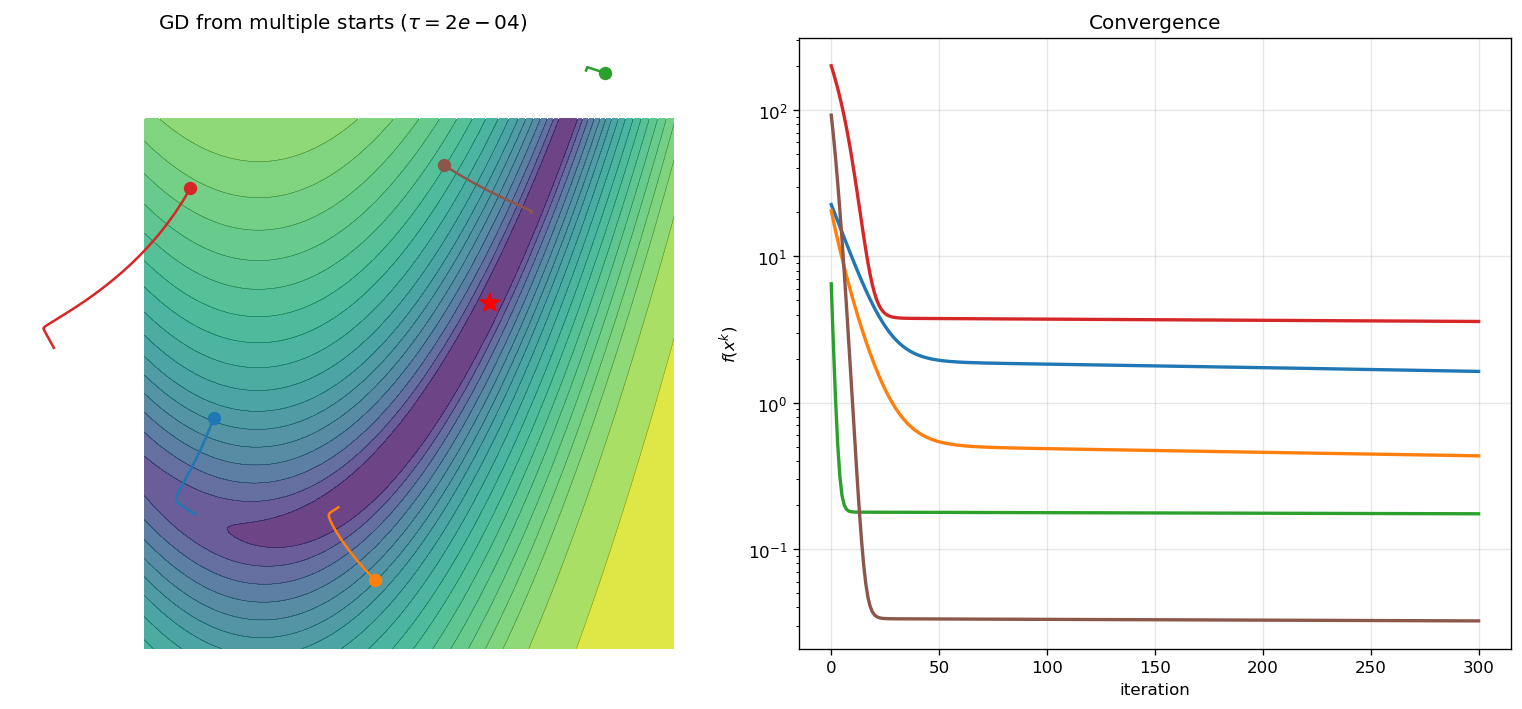

In [4]:
tau = 2e-4
starts = [(-0.2, 0.5), (0.5, -0.2), (1.5, 2.0), (-0.3, 1.5), (0.8, 1.6)]
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].contourf(xt, yt, F_log.T, levels=v, cmap='viridis', alpha=0.8)
axes[0].contour(xt, yt, F_log.T, levels=v, colors='k', linewidths=0.3, alpha=0.4)
axes[0].plot(1, 1, 'r*', ms=12)
cols2 = plt.cm.tab10(np.linspace(0, 0.5, len(starts)))

for (x0_, y0_), col in zip(starts, cols2):
    traj, fvals = gradient_descent(x0_, y0_, tau, 300)
    axes[0].plot(traj[:,0], traj[:,1], '-', lw=1.5, color=col)
    axes[0].plot(x0_, y0_, 'o', ms=7, color=col)
    axes[1].semilogy(fvals, lw=2, color=col)

axes[0].set_title(f'GD from multiple starts ($\\tau={tau:.0e}$)')
axes[0].set_aspect('equal'); axes[0].axis('off')
axes[1].set_xlabel('iteration'); axes[1].set_ylabel('$f(x^k)$')
axes[1].set_title('Convergence'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Interactive: step size and iterations

In [5]:
def show_gd(log_tau=-3.5, n_iter=150):
    tau = 10**log_tau
    traj, fvals = gradient_descent(1.2, 0.8, tau, n_iter)
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    axes[0].contourf(xt, yt, F_log.T, levels=v, cmap='viridis', alpha=0.8)
    axes[0].plot(traj[:,0], traj[:,1], 'w.-', lw=1.5, ms=4)
    axes[0].plot(1.2, 0.8, 'ko', ms=8); axes[0].plot(1, 1, 'r*', ms=12)
    axes[0].set_title(fr'Trajectory ($\tau={tau:.1e}$, {n_iter} steps)')
    axes[0].set_aspect('equal'); axes[0].axis('off')
    axes[1].semilogy(fvals, 'royalblue', lw=2)
    axes[1].set_xlabel('iteration'); axes[1].set_ylabel('$f(x^k)$')
    axes[1].set_title(f'Final $f = {fvals[-1]:.4f}$'); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

interact(show_gd,
         log_tau=FloatLogSlider(value=-3.5, min=-5.0, max=-2.5, step=0.25, description='$\\log_{10}\\tau$'),
         n_iter=IntSlider(value=150, min=20, max=500, step=20, description='iterations'));

interactive(children=(FloatLogSlider(value=1e-05, description='$\\log_{10}\\tau$', max=-2.5, min=-5.0, step=0.…

## Bibliographical resources

- Cauchy, A.-L. (1847). Méthode générale pour la résolution des systèmes d'équations simultanées. *Comptes Rendus de l'Académie des Sciences*, 25, 536–538.
- Rosenbrock, H. H. (1960). An automatic method for finding the greatest or least value of a function. *The Computer Journal*, 3(3), 175–184.
- Nesterov, Y. (2004). *Introductory Lectures on Stochastic Optimization*. Kluwer.
- Boyd, S. and Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press. Chapter 9.
- Nocedal, J. and Wright, S. J. (2006). *Numerical Optimization* (2nd ed.). Springer.